# Daily Temperatures

## Problem Description
Given an array of daily temperatures, return an array such that for each day, output the number of days you would have to wait until a warmer temperature. If there is no future day for which this is possible, put 0 instead.

## Example
```
Input: temperatures = [73,74,75,71,69,72,76,73]
Output: [1,1,4,2,1,1,0,0]
Explanation:
- Day 0: 73 → next warmer is 74 (1 day later)
- Day 1: 74 → next warmer is 75 (1 day later)
- Day 2: 75 → next warmer is 76 (4 days later)
- Day 3: 71 → next warmer is 72 (2 days later)
- Day 4: 69 → next warmer is 72 (1 day later)
- Day 5: 72 → next warmer is 76 (1 day later)
- Day 6: 76 → no warmer day (0)
- Day 7: 73 → no warmer day (0)

Input: temperatures = [30,40,50,60]
Output: [1,1,1,0]

Input: temperatures = [30,60,90]
Output: [1,1,0]
```

## Complexity
- **Time**: O(n) - each element pushed/popped once
- **Space**: O(n) - stack + output

## Key Concept: Monotonic Stack
A stack where elements are maintained in a specific order (increasing/decreasing). Perfect for finding the next greater/smaller element.

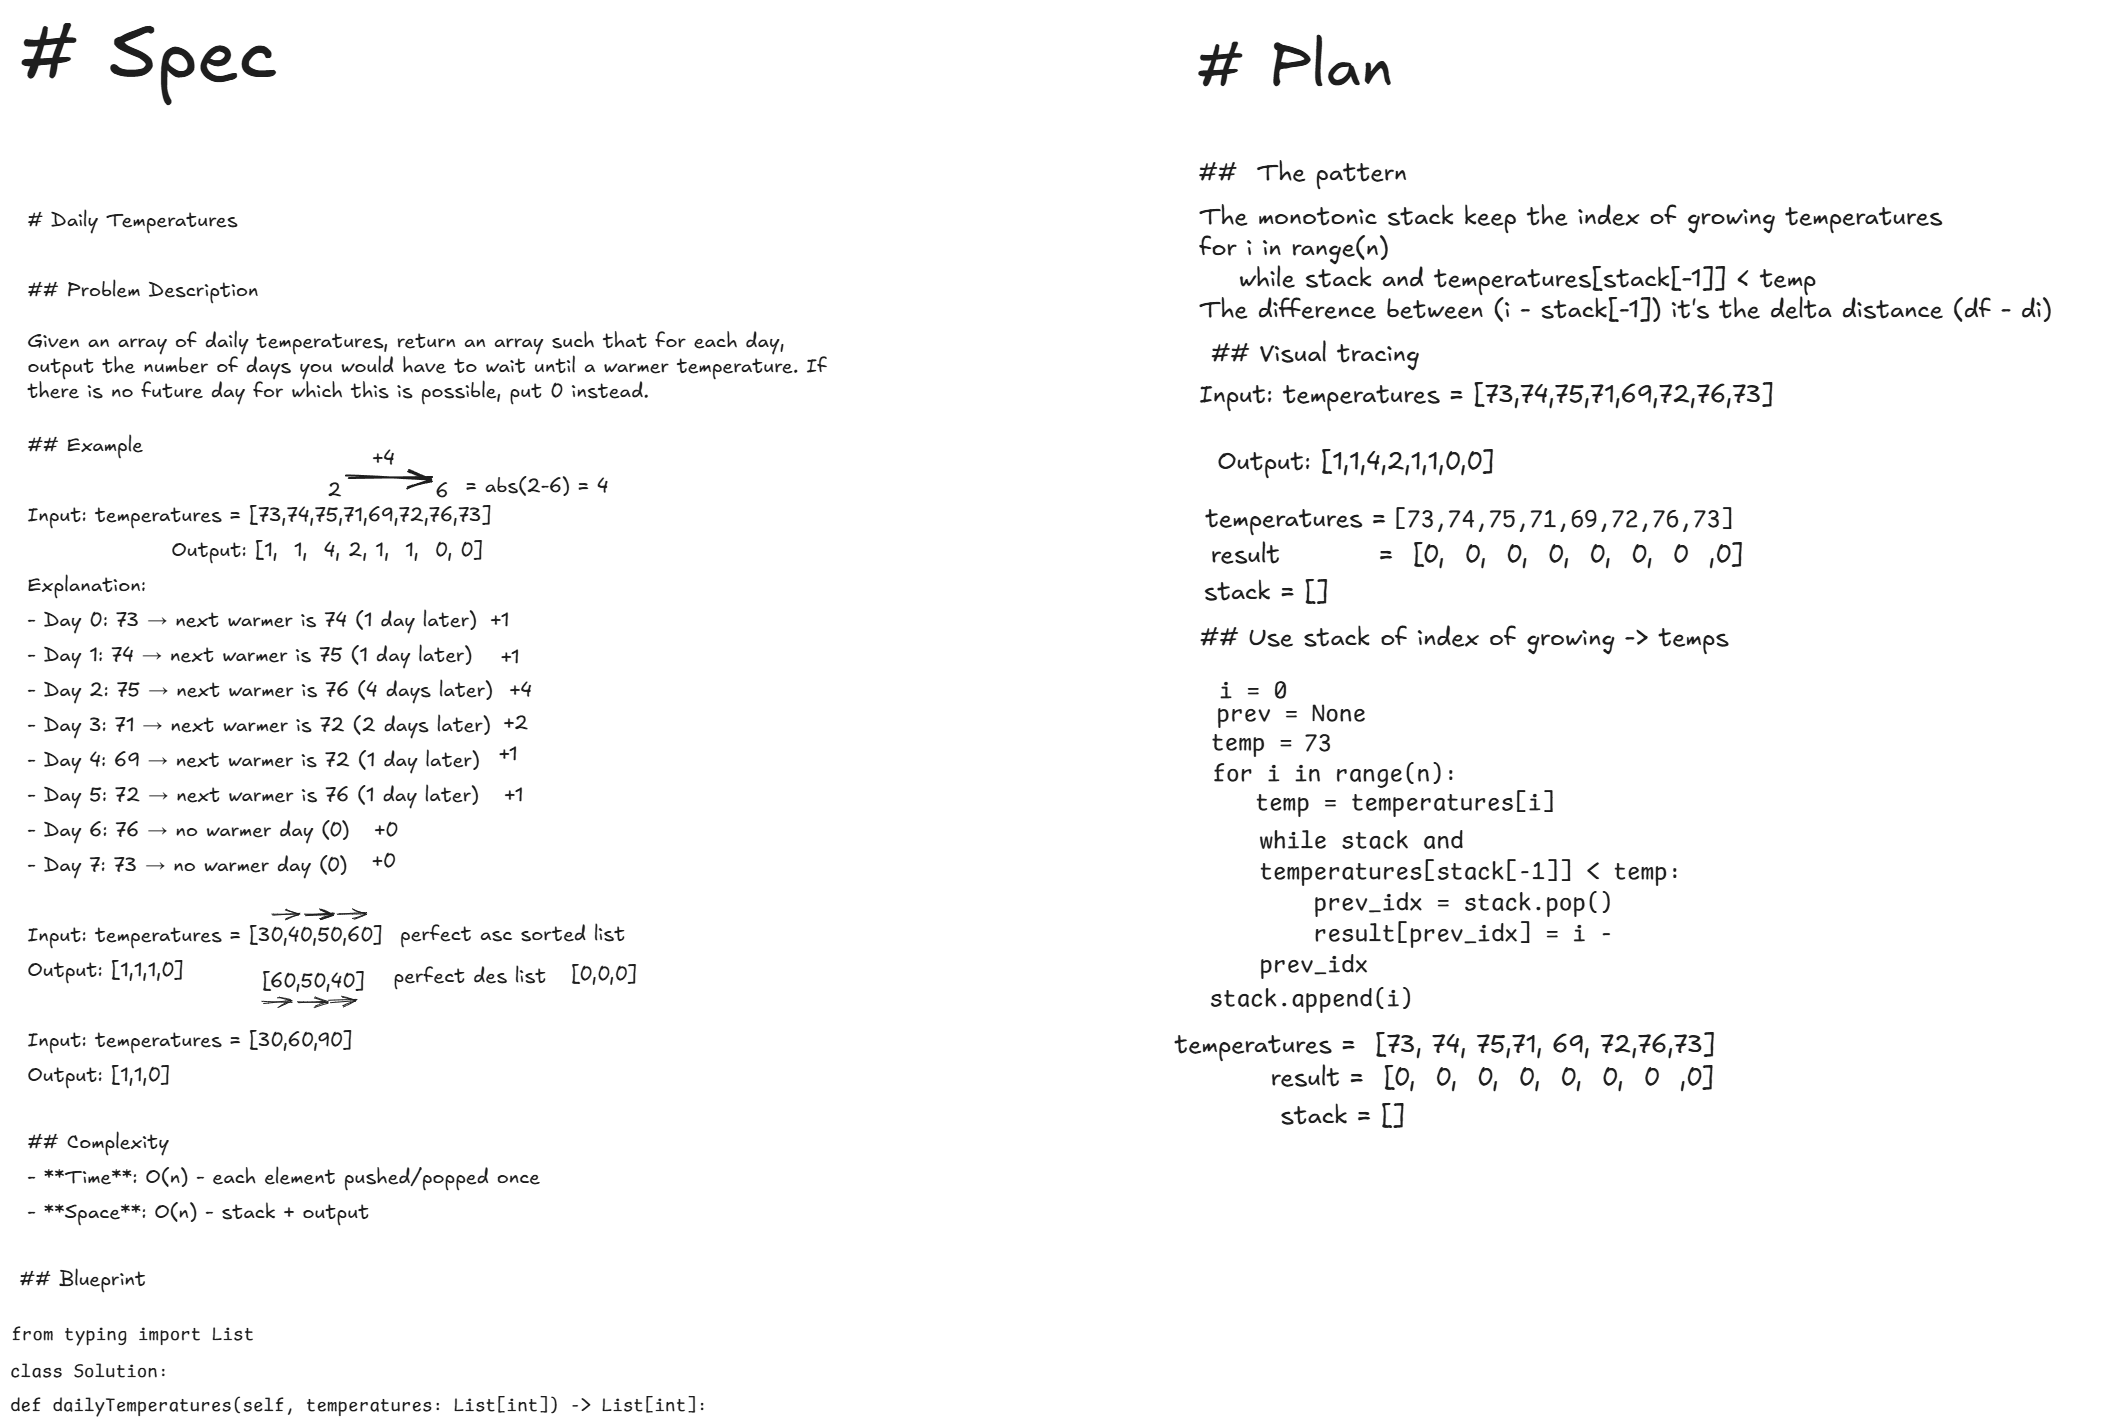

## Approach 1: Monotonic Decreasing Stack (Optimal)

### Key Idea:
- Use a **decreasing stack** of indices
- When we find a warmer day, pop indices from stack
- Calculate days difference: `current_day - popped_day`

### Algorithm:
1. Iterate through temperatures from left to right
2. While stack is not empty AND current temp > temp at stack top:
   - Pop index from stack
   - Record: `answer[popped_idx] = current_idx - popped_idx`
3. Push current index onto stack

### Example:
```
temperatures = [73,74,75,71,69,72,76,73]
                 0  1  2  3  4  5  6  7

i=0, T=73: stack=[], push 0 → stack=[0]

i=1, T=74: 74 > 73?
  - Pop 0: answer[0] = 1-0 = 1
  - push 1 → stack=[1]

i=2, T=75: 75 > 74?
  - Pop 1: answer[1] = 2-1 = 1
  - push 2 → stack=[2]

i=3, T=71: 71 > 75? No
  - push 3 → stack=[2,3]

i=4, T=69: 69 > 71? No
  - push 4 → stack=[2,3,4]

i=5, T=72: 72 > 69?
  - Pop 4: answer[4] = 5-4 = 1
  - 72 > 71? Pop 3: answer[3] = 5-3 = 2
  - 72 > 75? No
  - push 5 → stack=[2,5]

i=6, T=76: 76 > 72?
  - Pop 5: answer[5] = 6-5 = 1
  - 76 > 75? Pop 2: answer[2] = 6-2 = 4
  - push 6 → stack=[6]

i=7, T=73: 73 > 76? No
  - push 7 → stack=[6,7]

Final: answer = [1,1,4,2,1,1,0,0]
```

In [ ]:
from typing import List

class Solution:
    def dailyTemperatures(self, temperatures: List[int]) -> List[int]:
        """Monotonic stack approach - O(n) time, O(n) space"""
        n = len(temperatures)
        result = [0] * n
        stack = []  # Stack of indices
        
        for i, temp in enumerate(temperatures):
            # While stack not empty and current temp is warmer
            while stack and temperatures[stack[-1]] < temp:
                prev_idx = stack.pop()
                result[prev_idx] = i - prev_idx
            
            stack.append(i)
            print(f"Day {i}: stack indices = {stack}, temps = {[temperatures[idx] for idx in stack]}")
        
        return result

# Test
sol = Solution()
result = sol.dailyTemperatures([73,74,75,71,69,72,76,73])
print(f"\nResult: {result}\nExpected: [1,1,4,2,1,1,0,0]")

## Approach 2: Brute Force (Naive)

For each day, scan forward until finding a warmer day → O(n²) time

In [ ]:
class Solution2:
    def dailyTemperatures(self, temperatures: List[int]) -> List[int]:
        """Brute force - O(n²) time"""
        answer = [0] * len(temperatures)
        
        for i in range(len(temperatures)):
            for j in range(i + 1, len(temperatures)):
                if temperatures[j] > temperatures[i]:
                    answer[i] = j - i
                    break
        
        return answer

# Compare
sol1 = Solution()
sol2 = Solution2()
temps = [73,74,75,71,69,72,76,73]

result1 = sol1.dailyTemperatures(temps)
result2 = sol2.dailyTemperatures(temps)

print(f"\nMonotonic Stack: {result1}")
print(f"Brute Force: {result2}")

## Test Cases

In [ ]:
test_cases = [
    ([73,74,75,71,69,72,76,73], [1,1,4,2,1,1,0,0]),
    ([30,40,50,60], [1,1,1,0]),
    ([30,60,90], [1,1,0]),
    ([90,80,70,60,50,40], [0,0,0,0,0,0]),  # Decreasing
    ([50,50,50,50], [0,0,0,0]),  # All equal
]

print("Testing Daily Temperatures (Monotonic Stack):")
sol = Solution()
for temperatures, expected in test_cases:
    # Create a version without prints for clean testing
    pass

# Clean version
class SolutionClean:
    def dailyTemperatures(self, temperatures: List[int]) -> List[int]:
        n = len(temperatures)
        answer = [0] * n
        stack = []
        
        for i, temp in enumerate(temperatures):
            while stack and temperatures[stack[-1]] < temp:
                prev_idx = stack.pop()
                answer[prev_idx] = i - prev_idx
            stack.append(i)
        
        return answer

sol_clean = SolutionClean()
for temperatures, expected in test_cases:
    result = sol_clean.dailyTemperatures(temperatures)
    status = "✓" if result == expected else "✗"
    print(f"{status} {temperatures} → {result}")

## Key Insights

1. **Monotonic Stack**: Maintains elements in specific order for efficient searching
2. **Why decreasing stack?**: We pop when finding something larger (warmer)
3. **Time optimization**: From O(n²) brute force to O(n) with stack
4. **Space-time tradeoff**: Use extra space (stack) to save time

## Similar Problems Using Monotonic Stack
- Next Greater Element
- Previous Greater Element
- Largest Rectangle in Histogram (harder)
- Trapping Rain Water